## Data Collection and Initial Inspection


In [1]:
# importing the pandas library

import pandas as pd

# Load the dataset

df = pd.read_csv('Pharma_Industry.csv')

# show first five rows

print(df.head())
print('='*50)

# shape of the dataset

print('Shape of the dataset: ',df.shape)
print('='*50)

# check the datatypes

print(df.dtypes)
print('='*50)

# dataset information

print(df.info())
print('='*50)

# check the null values is there or not

print('no of null values: \n',df.isnull().sum())
print('='*50)

# check the duplicates records is there or not

print('no of duplicates records: ',df.duplicated().sum())
print('='*50)

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  
Shape of the dataset:  (500, 6)
Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg) 


## EDA(Exploratory Data Analysis)

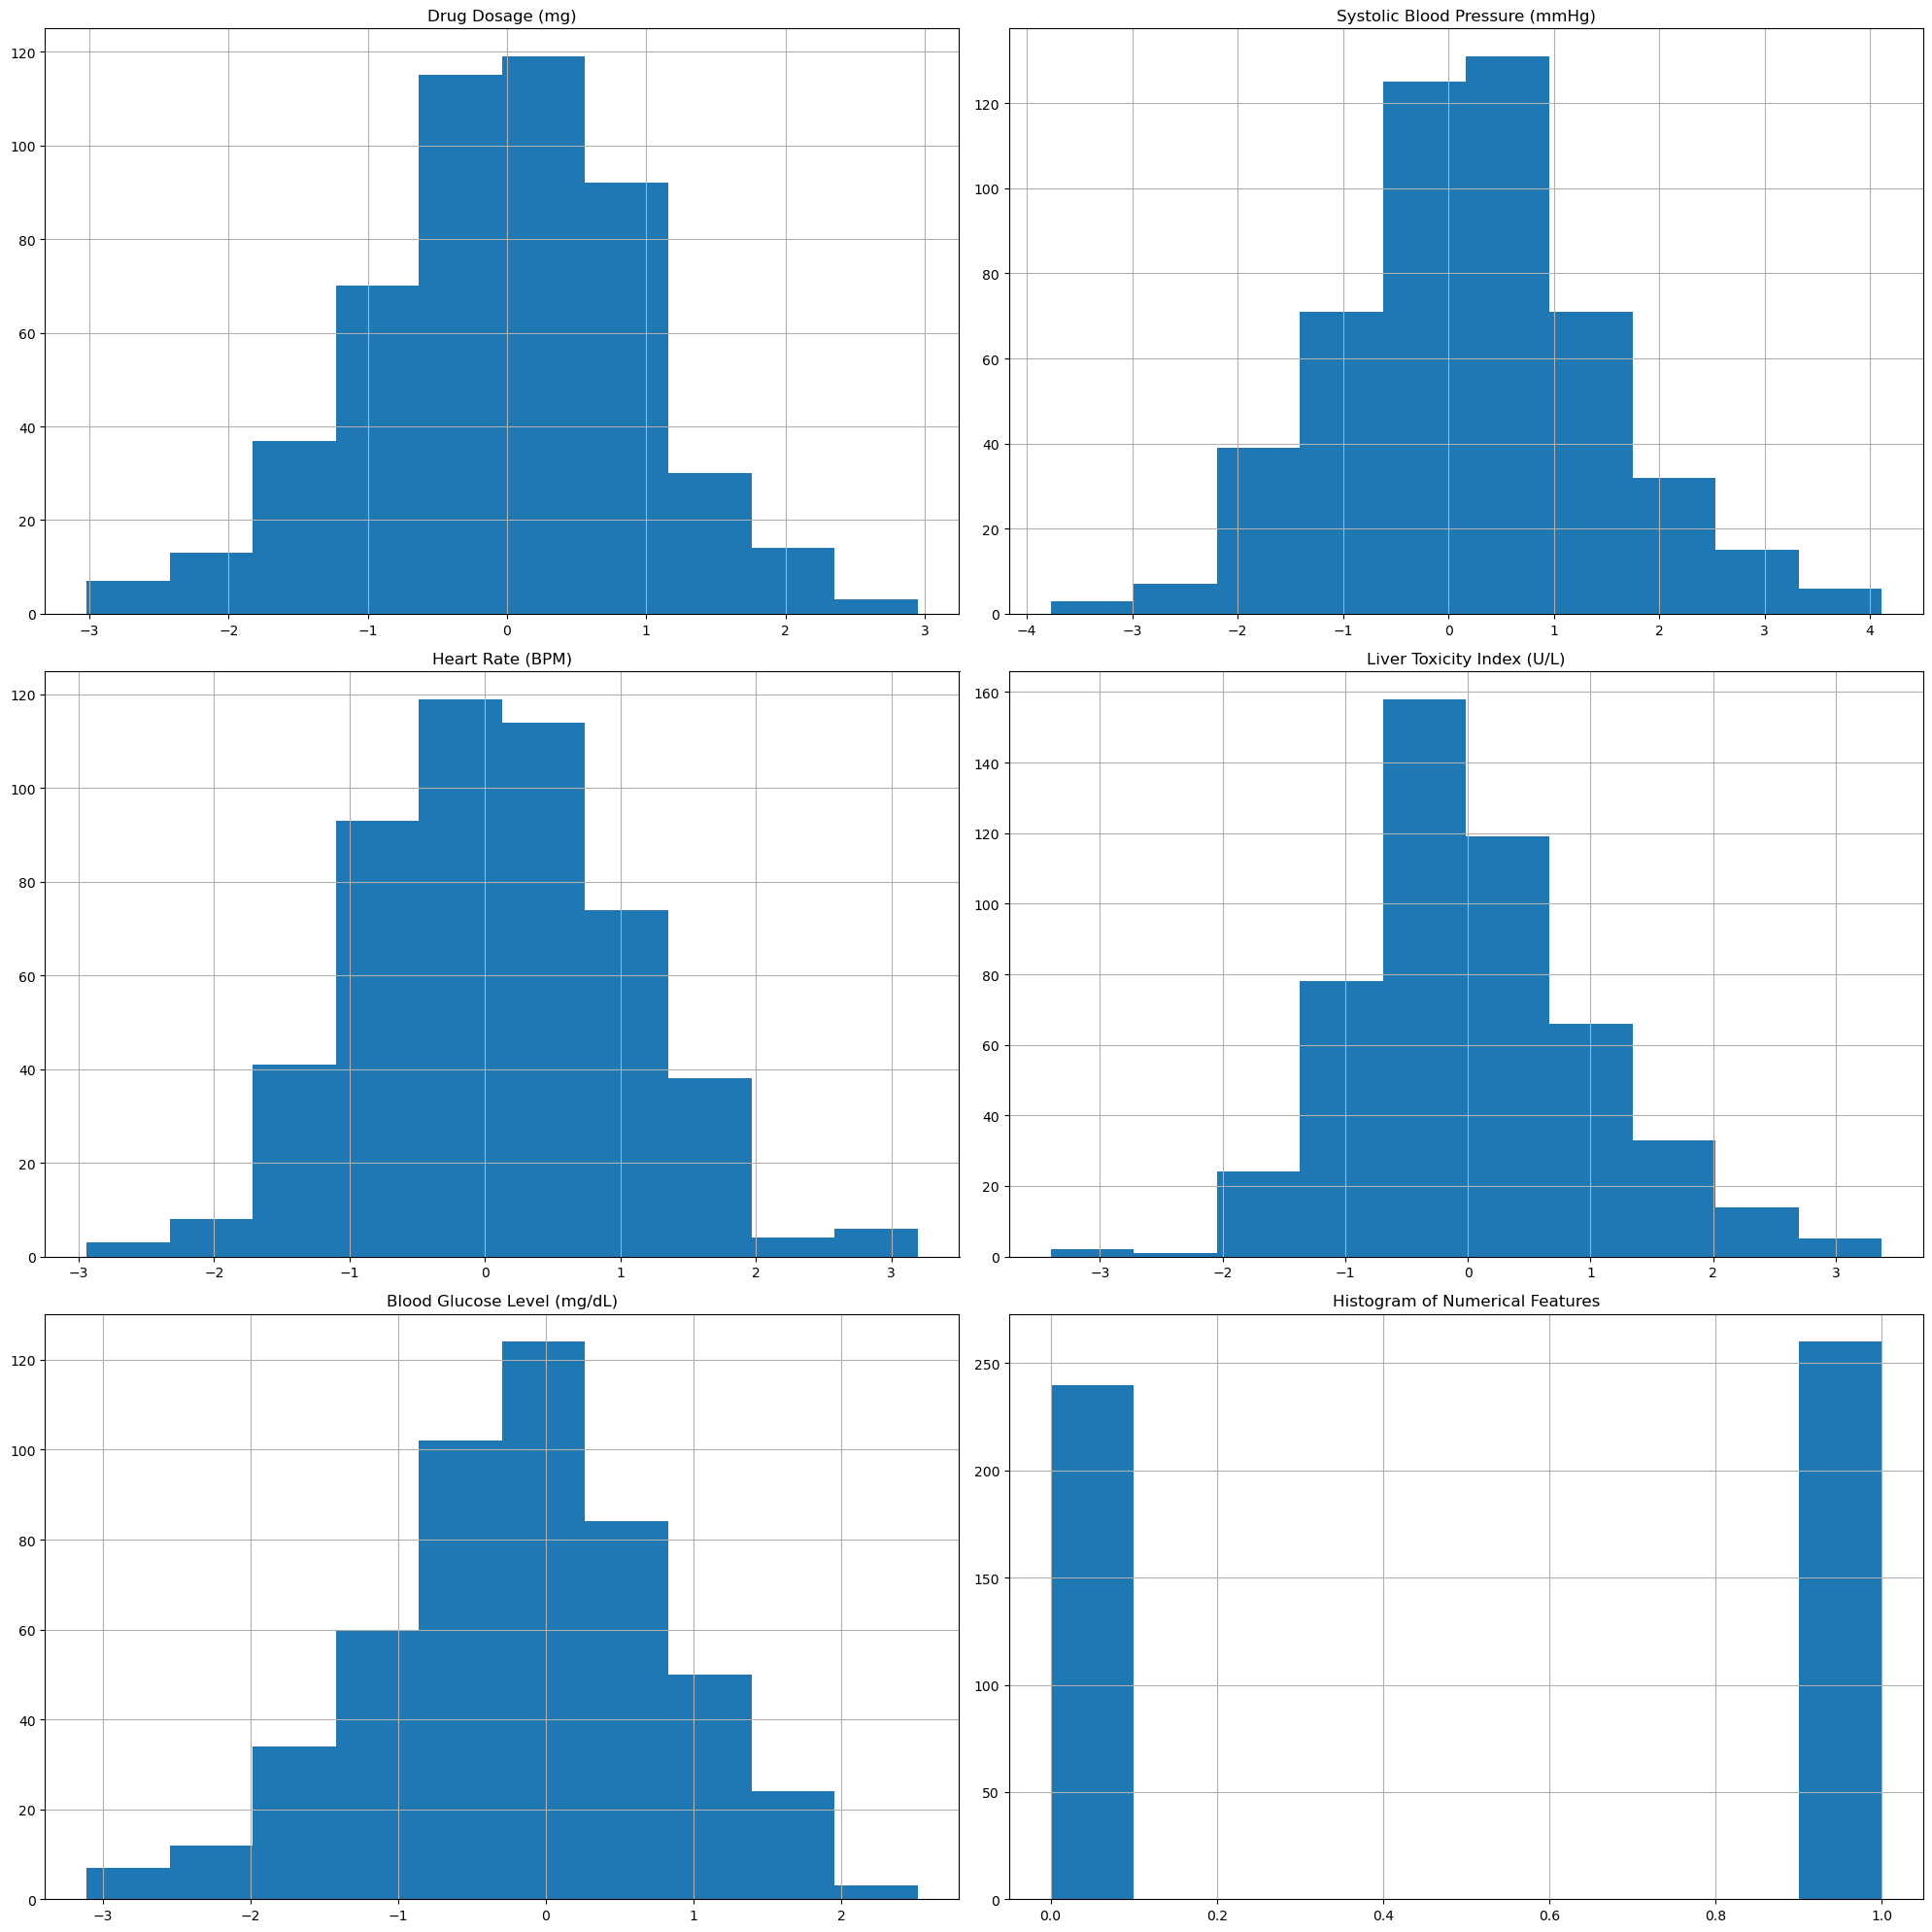

In [2]:


# importing matplotlib and seaborn libraries

import matplotlib.pyplot as plt
import seaborn as sns


# Histogram

df.hist(figsize = (20,20))
plt.title('Histogram of Numerical Features')
plt.tight_layout()
plt.show()


The histogram analysis indicates that all numerical features are approximately normally distributed with no severe skewness. The target variable (Drug Response) is balanced between the two classes (0 and 1). These distributions suggest that the dataset is well-suited for preprocessing using StandardScaler and for training an SVM classifier.

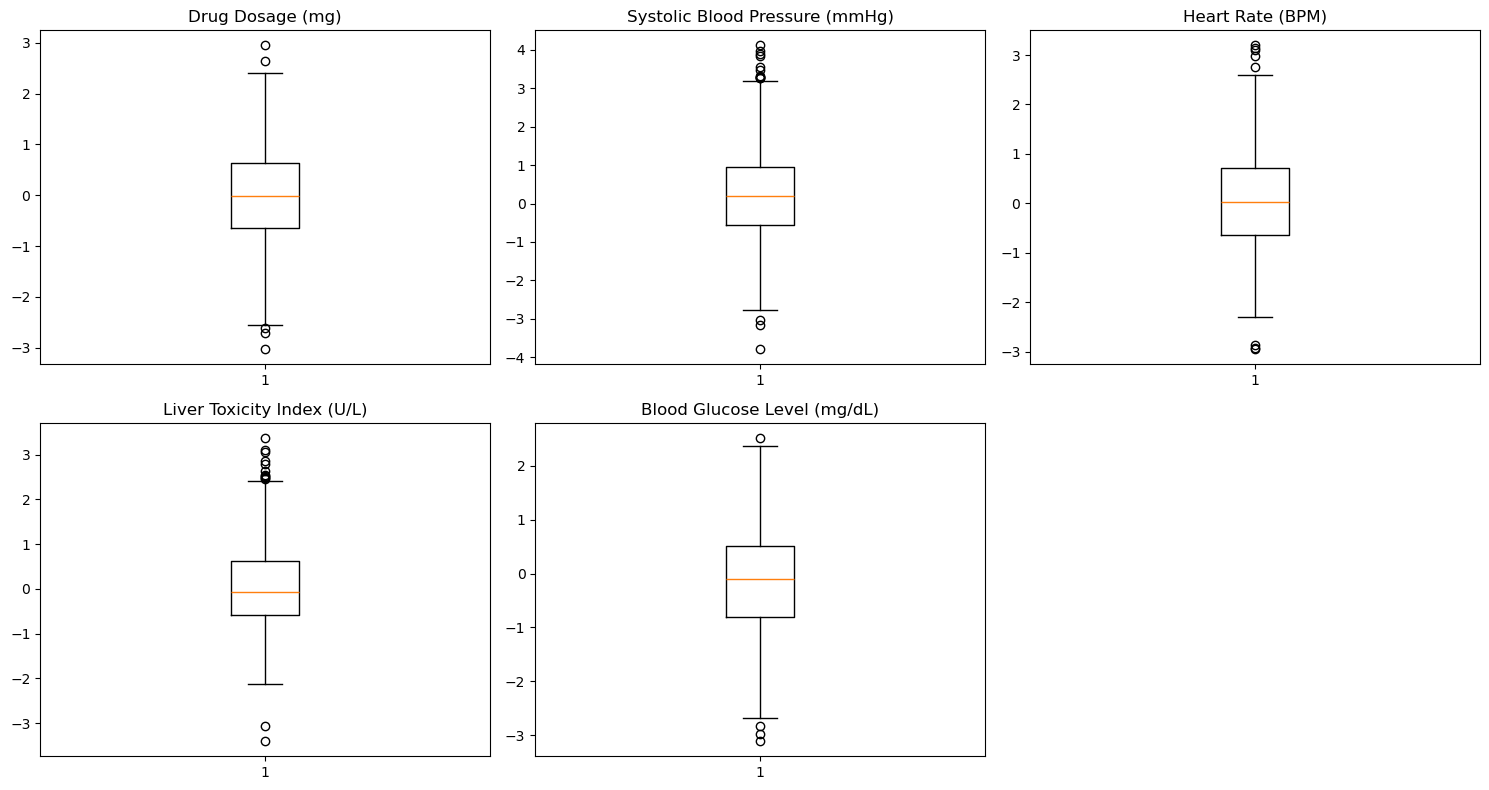

In [3]:
# Boxplot 

plt.figure(figsize=(15, 8))

for i, col in enumerate(df.columns[:-1]):   # Excluding target variable
    plt.subplot(2, 3, i + 1)
    plt.boxplot(df[col], vert=True)
    plt.title(col)

plt.tight_layout()
plt.show()


The box plots indicate that all numerical features contain a few outliers, but the majority of observations are concentrated within the interquartile range (IQR). The distributions are approximately symmetric, and no feature shows an excessive number of outliers.

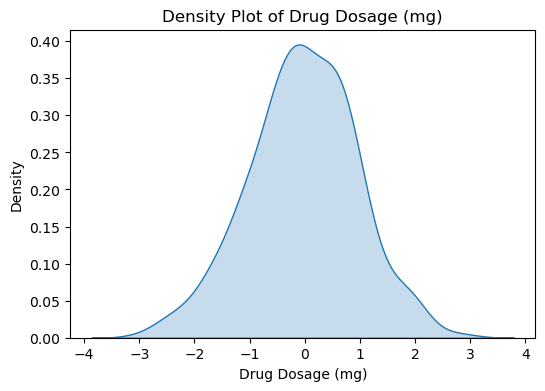

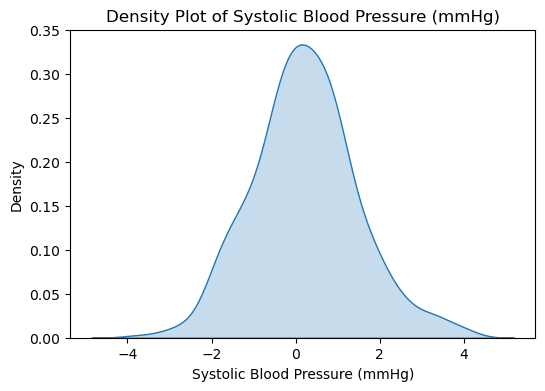

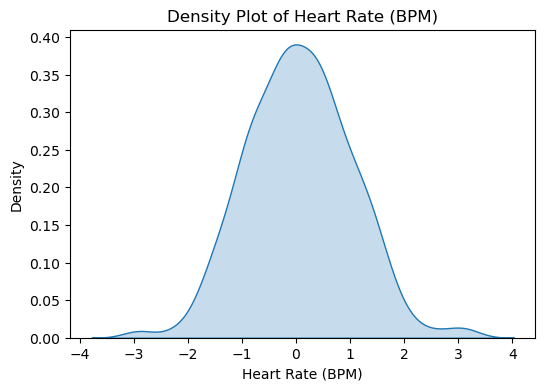

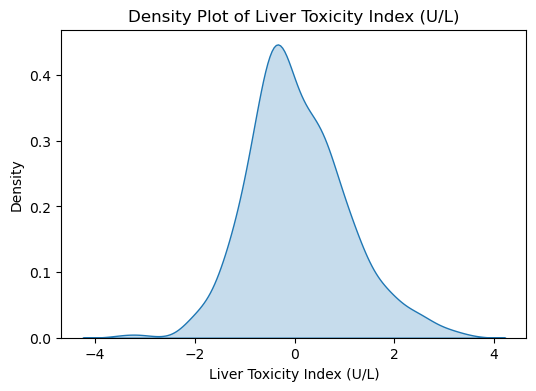

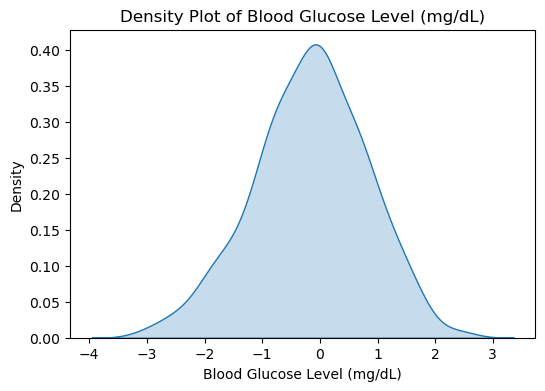

In [5]:
# Density plot

for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, fill=True)

    plt.title(f"Density Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.show()

In [7]:
print('Density plots (KDE) were used to visualize the probability distribution and assess the shape (normality or skewness) of each feature.')

Density plots (KDE) were used to visualize the probability distribution and assess the shape (normality or skewness) of each feature.


In [7]:
# Correlation Matrix

# Correlation Matrix
correlation = df.corr(numeric_only=True)

correlation

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


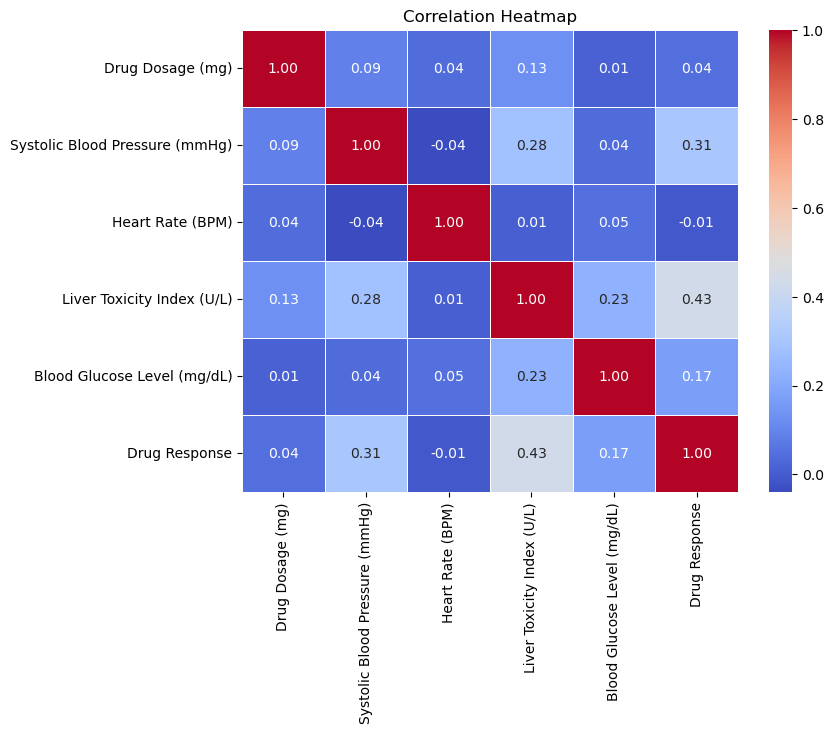

In [8]:
# Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Data Preprocessing

print(df.dtypes)

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object


All feature variables are numerical, and the target variable (Drug Response) is already encoded as 0 (No Response) and 1 (Positive Response). Therefore, no categorical encoding is required.

In [12]:
# Feature selection

X = df.drop("Drug Response", axis=1)

y = df["Drug Response"]


# Split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

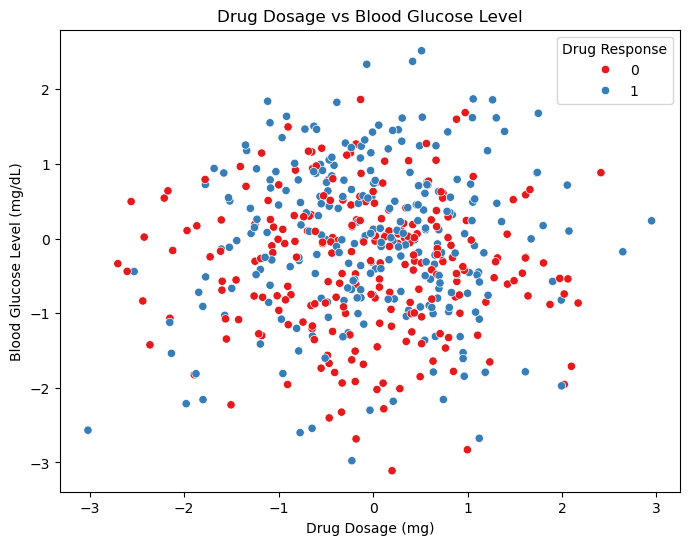

In [14]:
# Scatter Plot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Drug Dosage (mg)",
    y="Blood Glucose Level (mg/dL)",
    hue="Drug Response",
    palette="Set1"
)

plt.title("Drug Dosage vs Blood Glucose Level")
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Blood Glucose Level (mg/dL)")
plt.show()

The scatter plot illustrates the relationship between Drug Dosage and Blood Glucose Level. Different colors represent the two drug response classes (0 = No Response, 1 = Positive Response). The data points are spread across the feature space, showing the distribution of both classes.

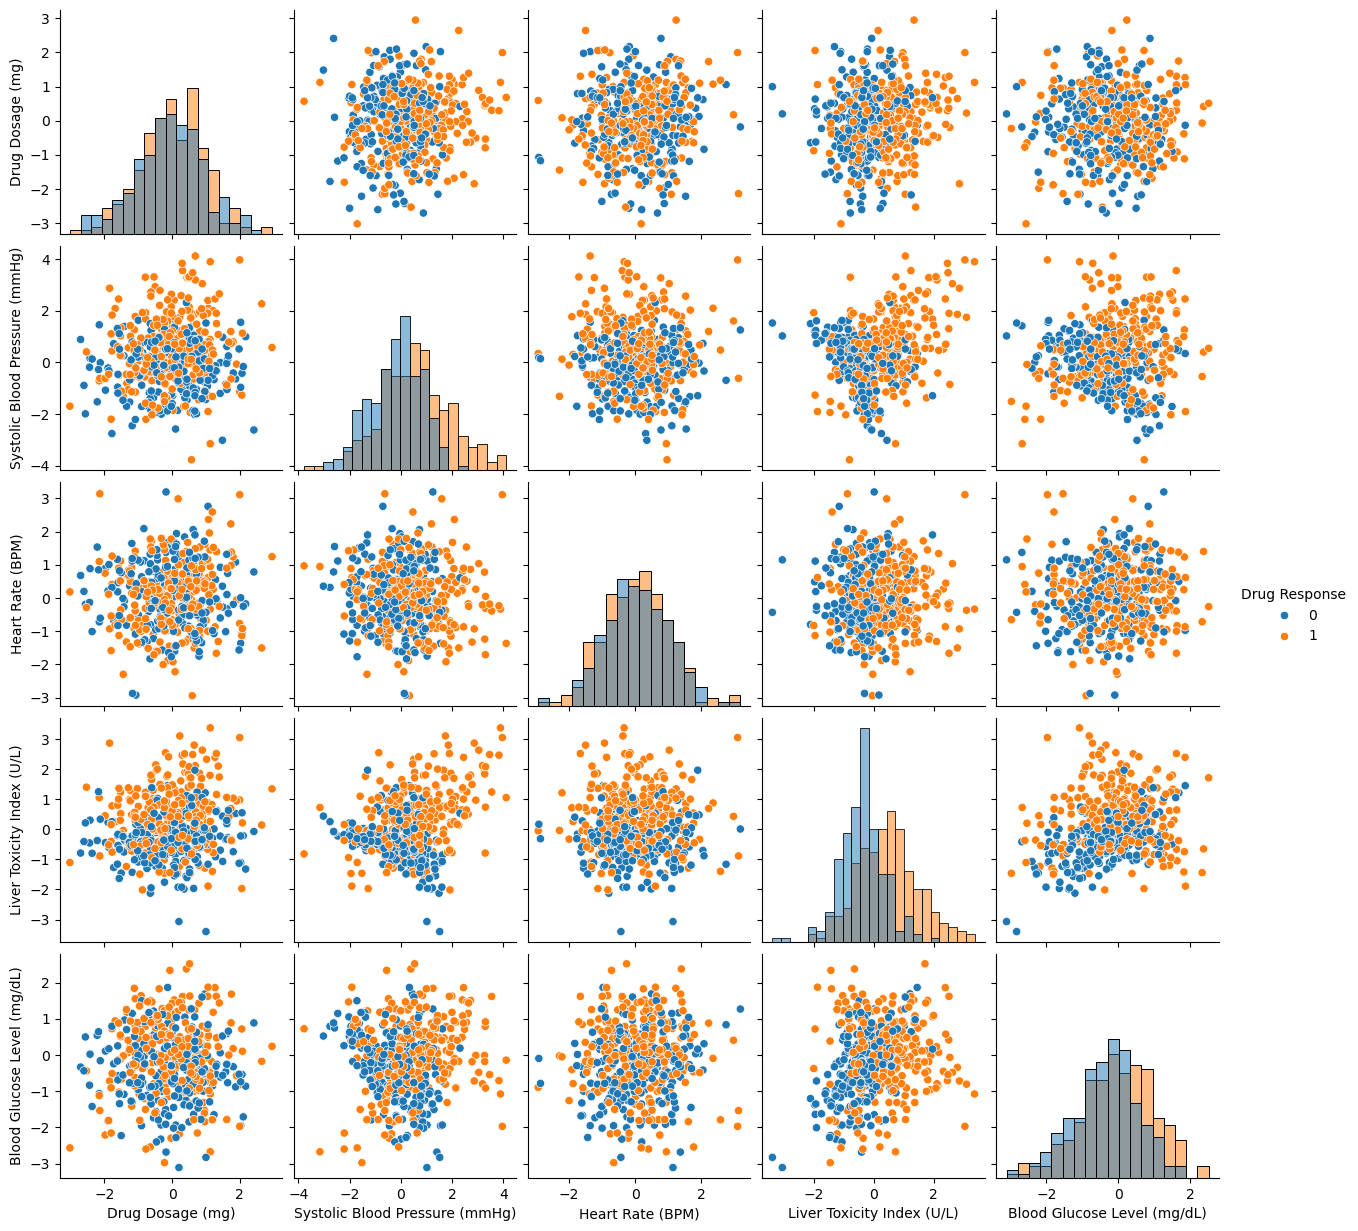

In [15]:
# Pair Plot

sns.pairplot(
    df,
    hue="Drug Response",
    diag_kind="hist"
)

plt.show()

In [16]:
The pair plot provides pairwise relationships among all numerical features. It helps identify patterns, trends, and possible class separation. The diagonal plots show the distribution of each feature, while the scatter plots illustrate relationships between feature pairs.

SyntaxError: invalid syntax (760704493.py, line 1)

In [ ]:
# count plot

plt.figure(figsize=(6,4))

sns.countplot(
    x="Drug Response",
    data=df
)

plt.title("Drug Response Class Distribution")
plt.xlabel("Drug Response")
plt.ylabel("Count")

plt.show()

In [18]:
# Support Vector Machine

from sklearn.svm import SVC

# Model Selection

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

# Model fitting

svm_model.fit(X_train,y_train)


# Predictions

y_pred = svm_model.predict(X_test)

## Evalution


In [19]:

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)



print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.77
Precision : 0.7543859649122807
Recall : 0.8269230769230769
F1 Score : 0.7889908256880734


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[34 14]
 [ 9 43]]


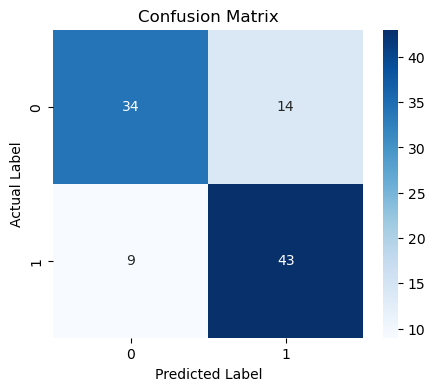

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [23]:
# GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf'],
    'gamma': ['scale', 'auto']
}


grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross Validation Score:")
print(grid_search.best_score_)

best_svm = grid_search.best_estimator_

y_pred_best = best_svm.predict(X_test)


print("Accuracy :", accuracy_score(y_test, y_pred_best))

print(classification_report(y_test, y_pred_best))

Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Score:
0.7525000000000001
Accuracy : 0.77
              precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



In [24]:
# compare SVM Performance with Different kernels

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

kernels = ['linear', 'poly', 'rbf']

results = []

for kernel in kernels:
    
    model = SVC(kernel=kernel, random_state=42)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Kernel": kernel,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Kernel,Accuracy,Precision,Recall,F1-Score
0,linear,0.72,0.760870,0.673077,0.714286
1,poly,0.65,0.666667,0.653846,0.660194
2,rbf,0.77,0.754386,0.826923,0.788991



The RBF kernel achieved the highest accuracy, indicating that it captures non-linear relationships in the data more effectively than the Linear and Polynomial kernels. Therefore, the RBF kernel was selected as the best-performing model for this dataset.


Strengths: 

1. SVM performs well on binary classification problems such as drug response prediction.
2. It is effective even with a relatively small dataset.
3. Standardized numerical features improve SVM performance.
4. The RBF kernel captures non-linear relationships between patient health measurements and drug response.
5. The dataset is balanced, reducing the risk of bias toward one class.

Weaknesses:


1. SVM requires feature scaling before training.
2. Choosing the appropriate kernel and hyperparameters can be time-consuming.
3. Training can become slow for very large datasets.
4. SVM models are less interpretable than simpler models such as Decision Trees.



Healthcare:

1. Predict whether a patient will respond positively to a drug.
2. Support personalized medicine by helping doctors choose effective treatments.
3. Reduce the cost and time of clinical trials by identifying likely responders early.
4. Assist researchers in evaluating the effectiveness of new drugs.

In Real - World Aplications:

1. Disease Diagnosis
2. Cancer Detection
3. Email spam filtering



In [25]:
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
import joblib

# Save the scaler
joblib.dump(scaler, "scaler1.pkl")

# Save the best SVM model
joblib.dump(best_svm, "svm_model.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [28]:
best_svm = grid_search.best_estimator_

In [29]:
joblib.dump(best_svm, "svm_model.pkl")

['svm_model.pkl']

In [30]:
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

y_pred_best = best_svm.predict(X_test)

In [31]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)